# Tarea Clase 1 — Deep Learning (UAI)

**Autor:** _[Completar nombre]_  
**Curso:** Deep Learning  
**Fecha:** _[Completar fecha]_

## 1) Introducción

En esta tarea construyo y analizo un **Multilayer Perceptron (MLP)** para clasificación de imágenes manuscritas. El objetivo es conectar la teoría de la Clase 1 (perceptrón, limitación con XOR, capas ocultas, activaciones y backpropagation) con una implementación real en un problema supervisado de clasificación multiclase.

Trabajaré con **MNIST** y compararé dos versiones del modelo: una base y otra mejorada con regularización y *Early Stopping*.

## 2) Marco teórico

### ¿Qué es un perceptrón?
Un perceptrón es el bloque más simple de una red neuronal: recibe entradas, calcula una combinación lineal y aplica una función de activación para producir una salida.

### ¿Qué problema resuelve?
Puede resolver problemas **linealmente separables**, por ejemplo cuando una sola recta (o hiperplano) separa las clases.

### ¿Por qué no puede resolver XOR?
XOR no es linealmente separable: no existe una sola frontera lineal que separe correctamente sus clases. Por eso un perceptrón de una sola capa falla en XOR.

### ¿Qué es un MLP?
Un **MLP** agrega una o más capas ocultas entre entrada y salida. Esto permite aprender transformaciones no lineales y representar fronteras de decisión más complejas.

### Rol de las capas ocultas
Las capas ocultas aprenden representaciones intermedias útiles del dato. En imágenes, pueden combinar patrones básicos para formar características más informativas para clasificar.

### Funciones de activación (ReLU y Sigmoid)
- **ReLU**: introduce no linealidad de forma eficiente y suele entrenar más rápido.
- **Sigmoid**: acota salidas entre 0 y 1, útil en ciertos contextos, pero puede saturarse en redes profundas.

### ¿Qué es backpropagation (conceptual)?
Backpropagation es el mecanismo para ajustar pesos: calcula cuánto aportó cada parámetro al error final y actualiza los pesos en dirección de menor pérdida (normalmente usando descenso de gradiente y variantes como Adam).

### Conexión teoría–implementación
En esta tarea, el paso de un perceptrón simple a un MLP con activaciones no lineales explica por qué el modelo puede resolver tareas complejas como clasificación de dígitos, donde una frontera lineal única es insuficiente.

In [20]:
# Instalación automática de dependencias (solo si faltan)
import importlib
import subprocess
import sys

required = {
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'sklearn': 'scikit-learn',
    'tensorflow': 'tensorflow'
}

missing = []
for module_name, package_name in required.items():
    try:
        importlib.import_module(module_name)
    except Exception:
        missing.append(package_name)

if missing:
    print('Instalando paquetes faltantes:', missing)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + missing)
else:
    print('Todas las dependencias ya están instaladas.')

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print('TensorFlow:', tf.__version__)

Todas las dependencias ya están instaladas.
TensorFlow: 2.19.0


In [21]:
# Reproducibilidad
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# (Opcional) para mayor determinismo en CPU/GPU
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

## 3) Carga y Exploración de Datos (EDA)

In [22]:
# Carga de MNIST
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()

# Trabajar sobre copia de datos (buena práctica)
X_train_full = X_train_full.copy()
y_train_full = y_train_full.copy()
X_test = X_test.copy()
y_test = y_test.copy()

print('X_train_full:', X_train_full.shape)
print('y_train_full:', y_train_full.shape)
print('X_test:', X_test.shape)
print('y_test:', y_test.shape)

X_train_full: (60000, 28, 28)
y_train_full: (60000,)
X_test: (10000, 28, 28)
y_test: (10000,)


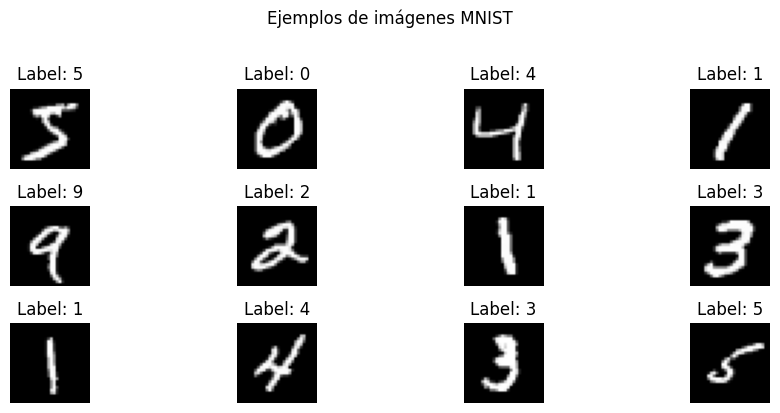

In [23]:
# Visualizar ejemplos
plt.figure(figsize=(10, 4))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train_full[i], cmap='gray')
    plt.title(f'Label: {y_train_full[i]}')
    plt.axis('off')
plt.suptitle('Ejemplos de imágenes MNIST', y=1.02)
plt.tight_layout()
plt.show()

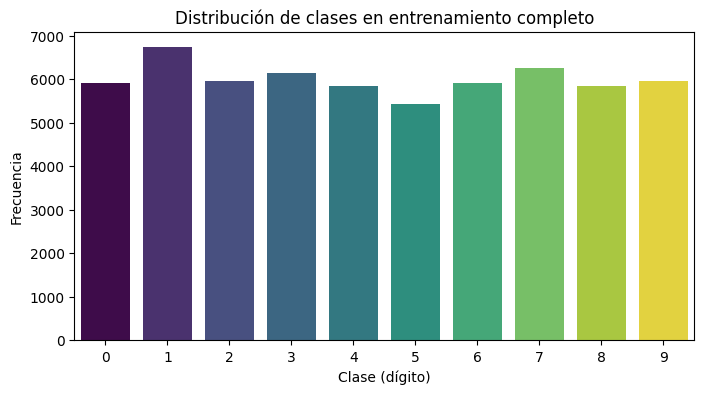

{np.uint8(0): np.int64(5923), np.uint8(1): np.int64(6742), np.uint8(2): np.int64(5958), np.uint8(3): np.int64(6131), np.uint8(4): np.int64(5842), np.uint8(5): np.int64(5421), np.uint8(6): np.int64(5918), np.uint8(7): np.int64(6265), np.uint8(8): np.int64(5851), np.uint8(9): np.int64(5949)}


In [24]:
# Distribución de clases
classes, counts = np.unique(y_train_full, return_counts=True)
plt.figure(figsize=(8, 4))
sns.barplot(x=classes, y=counts, palette='viridis', hue=classes, legend=False)
plt.title('Distribución de clases en entrenamiento completo')
plt.xlabel('Clase (dígito)')
plt.ylabel('Frecuencia')
plt.show()

print(dict(zip(classes, counts)))

## 4) Preprocesamiento

- **Normalización:** escalamos pixeles de [0, 255] a [0, 1] para estabilizar entrenamiento.
- **Flatten:** MLP espera vectores, por eso convertimos cada imagen 28x28 en vector de 784.
- **Split train/validation/test:** separamos validación para monitorear generalización durante entrenamiento.
- **Etiquetas:** usamos enteros de clase y `sparse_categorical_crossentropy` (no requiere one-hot).

In [25]:
# Normalización
X_train_full = X_train_full.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Flatten: (n, 28, 28) -> (n, 784)
X_train_full_flat = X_train_full.reshape(-1, 28 * 28)
X_test_flat = X_test.reshape(-1, 28 * 28)

# Train / Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full_flat,
    y_train_full,
    test_size=0.1,
    random_state=SEED,
    stratify=y_train_full,
)

print('X_train:', X_train.shape)
print('X_val:', X_val.shape)
print('X_test:', X_test_flat.shape)

X_train: (54000, 784)
X_val: (6000, 784)
X_test: (10000, 784)


## 5) Construcción del Modelo (MLP base)

Arquitectura base:
- Capa de entrada de tamaño 784 (imagen aplanada).
- Dos capas ocultas densas con ReLU para modelar no linealidades.
- Capa de salida de 10 neuronas (una por dígito) con `softmax` para probabilidades por clase.

In [26]:
def build_base_mlp(input_dim=784, num_classes=10):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

base_model = build_base_mlp()
base_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## 6) Compilación y Entrenamiento

In [ ]:
base_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_base = base_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=12,
    batch_size=128,
    verbose=1
)

Epoch 1/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9031 - loss: 0.3451 - val_accuracy: 0.9465 - val_loss: 0.1909
Epoch 2/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9565 - loss: 0.1463 - val_accuracy: 0.9585 - val_loss: 0.1468
Epoch 3/12
156/422 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9630 - loss: 0.1221

## 7) Análisis de Entrenamiento

In [ ]:
def plot_history(history, title_prefix='Modelo'):
    hist = history.history
    epochs = range(1, len(hist['loss']) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, hist['loss'], label='Train Loss')
    plt.plot(epochs, hist['val_loss'], label='Val Loss')
    plt.title(f'{title_prefix} - Pérdida')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, hist['accuracy'], label='Train Acc')
    plt.plot(epochs, hist['val_accuracy'], label='Val Acc')
    plt.title(f'{title_prefix} - Accuracy')
    plt.xlabel('Época')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_base, title_prefix='MLP Base')

**Interpretación inicial:**

Si la curva de entrenamiento mejora pero validación se estanca o empeora, hay señales de **overfitting**. Si ambas curvas quedan bajas, puede haber **underfitting**. Estas observaciones guían la mejora de arquitectura y regularización.

## 8) Evaluación del Modelo (test set)

In [ ]:
test_loss_base, test_acc_base = base_model.evaluate(X_test_flat, y_test, verbose=0)
print(f'Base - Test Loss: {test_loss_base:.4f}')
print(f'Base - Test Accuracy: {test_acc_base:.4f}')

## 9) Análisis Profundo

In [ ]:
# Predicciones del modelo base
y_proba_base = base_model.predict(X_test_flat, verbose=0)
y_pred_base = np.argmax(y_proba_base, axis=1)

# Matriz de confusión
cm_base = confusion_matrix(y_test, y_pred_base)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusión - MLP Base')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta real')
plt.show()

print('Reporte de clasificación (base):')
print(classification_report(y_test, y_pred_base, digits=4))

In [ ]:
# Ejemplos mal clasificados
mis_idx = np.where(y_pred_base != y_test)[0]
print(f'Total mal clasificados (base): {len(mis_idx)}')

n_show = 12
show_idx = mis_idx[:n_show]

plt.figure(figsize=(12, 6))
for i, idx in enumerate(show_idx):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[idx], cmap='gray')
    plt.title(f'Real: {y_test[idx]} | Pred: {y_pred_base[idx]}')
    plt.axis('off')
plt.suptitle('Ejemplos mal clasificados (MLP Base)', y=1.02)
plt.tight_layout()
plt.show()

**Interpretación de errores:**

Los errores suelen concentrarse en dígitos visualmente similares (por ejemplo 4/9, 3/5, 7/9), especialmente cuando la escritura es ambigua. Esto refleja una limitación del MLP con entrada aplanada: pierde estructura espacial local de la imagen.

## 10) Mejora del Modelo

Se implementa una mejora combinada:
1. **Dropout** para regularización (reducir overfitting).
2. **EarlyStopping** para detener entrenamiento cuando la validación deja de mejorar.

Luego se compara **ANTES vs DESPUÉS**.

In [ ]:
def build_improved_mlp(input_dim=784, num_classes=10):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

improved_model = build_improved_mlp()
improved_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_improved = improved_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

In [ ]:
plot_history(history_improved, title_prefix='MLP Mejorado')

test_loss_imp, test_acc_imp = improved_model.evaluate(X_test_flat, y_test, verbose=0)
print(f'Mejorado - Test Loss: {test_loss_imp:.4f}')
print(f'Mejorado - Test Accuracy: {test_acc_imp:.4f}')

print('Comparación (ANTES vs DESPUÉS)')
print(f'Accuracy base     : {test_acc_base:.4f}')
print(f'Accuracy mejorado : {test_acc_imp:.4f}')
print(f'Diferencia        : {test_acc_imp - test_acc_base:+.4f}')

In [ ]:
# Matriz de confusión modelo mejorado
y_proba_imp = improved_model.predict(X_test_flat, verbose=0)
y_pred_imp = np.argmax(y_proba_imp, axis=1)

cm_imp = confusion_matrix(y_test, y_pred_imp)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_imp, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de confusión - MLP Mejorado')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta real')
plt.show()

## 11) Conclusiones

1. **Aprendizaje logrado:** el paso de perceptrón simple a MLP permite modelar relaciones no lineales, haciendo viable la clasificación multiclase en imágenes.
2. **Limitaciones del MLP:** al aplanar la imagen, el modelo ignora la estructura espacial local (vecindad de píxeles), lo que afecta casos ambiguos.
3. **Por qué una CNN sería mejor:** las CNN explotan patrones espaciales mediante convoluciones y *pooling*, por eso suelen superar a un MLP en visión por computador.
4. **Relación con la clase:** esta implementación aterriza conceptos centrales de la Clase 1: perceptrón, activaciones, backpropagation, aprendizaje supervisado y necesidad de arquitecturas más expresivas.

---
### Checklist de entrega
- [x] Marco teórico conectado con implementación.
- [x] EDA y preprocesamiento claros.
- [x] Modelo base + modelo mejorado.
- [x] Curvas de entrenamiento y análisis.
- [x] Matriz de confusión + ejemplos mal clasificados.
- [x] Conclusiones alineadas a teoría de la clase.